# Computer Vision Lab 06 — solved tasks

This notebook solves **all three Lab Timing exercises and all five Lab Tasks** in the supplied task sheet. It follows the methods explained in the supplied lab manual. The manual is titled *Lab 05*, but its topics match these tasks.

Run cells from top to bottom. No extra image, video, or data files are needed: each example makes a small sample input. For a real project, replace the generated sample with your own `cv2.imread(...)`, video frames, or sensor readings. The sample results demonstrate the method; they are not a trained real-world detector.

**Packages:** `opencv-python`, `numpy`, and `matplotlib`. OpenCV must include `cv2.SIFT_create`.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tempfile
from pathlib import Path

def show_images(images, titles, size=(12, 4)):
    plt.figure(figsize=size)
    for i, (image, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, len(images), i)
        if image.ndim == 2:
            plt.imshow(image, cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def sift_location(reference, scene):
    """Return the four corners of a matched reference object in a scene."""
    sift = cv2.SIFT_create()
    ref_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
    key1, desc1 = sift.detectAndCompute(ref_gray, None)
    key2, desc2 = sift.detectAndCompute(scene_gray, None)
    if desc1 is None or desc2 is None:
        return None, 0
    pairs = cv2.BFMatcher().knnMatch(desc1, desc2, k=2)
    good = [a for a, b in pairs if a.distance < 0.75 * b.distance]
    if len(good) < 4:
        return None, len(good)
    src = np.float32([key1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([key2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None or int(mask.sum()) < 4:
        return None, len(good)
    h, w = reference.shape[:2]
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(corners, H).astype(int), int(mask.sum())

# A textured asset that gives SIFT distinct features.
rng = np.random.default_rng(6)
asset = np.full((120, 180, 3), 235, np.uint8)
cv2.rectangle(asset, (2, 2), (177, 117), (25, 25, 25), 3)
for _ in range(45):
    x, y = rng.integers(10, 170), rng.integers(10, 110)
    color = tuple(int(v) for v in rng.integers(20, 215, 3))
    cv2.circle(asset, (int(x), int(y)), int(rng.integers(2, 6)), color, -1)
cv2.putText(asset, 'PC-07', (18, 68), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)


## Lab Timing 1 — computer screen detection

The manual describes Canny edges followed by the **Hough line transform**. Lines show likely screen borders. A contour groups those borders into one rectangle per screen. The simple brightness check labels each sample screen on or off. This is a controlled demonstration; real lab photos need tuned thresholds and perspective handling.


Screens found: 3 | Status: ['ON', 'OFF', 'ON']


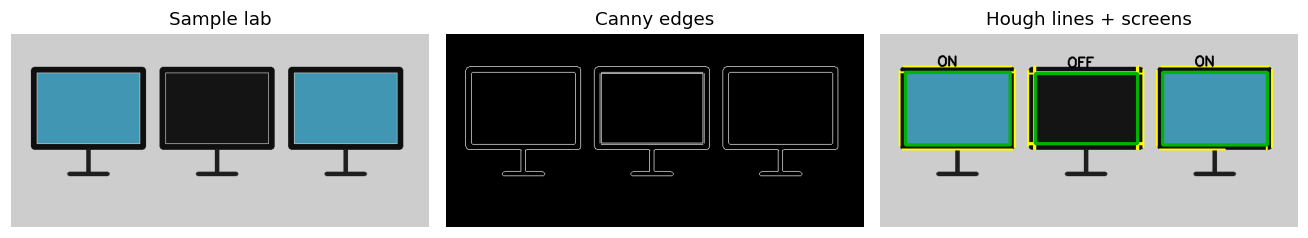

In [4]:
lab = np.full((300, 650, 3), 205, np.uint8)
for x, on in [(35, True), (235, False), (435, True)]:
    cv2.rectangle(lab, (x, 55), (x + 170, 175), (15, 15, 15), 8)
    color = (180, 150, 65) if on else (20, 20, 20)
    cv2.rectangle(lab, (x + 6, 61), (x + 164, 169), color, -1)
    cv2.line(lab, (x + 85, 180), (x + 85, 215), (30, 30, 30), 5)
    cv2.line(lab, (x + 55, 217), (x + 115, 217), (30, 30, 30), 5)

gray = cv2.cvtColor(lab, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 70, minLineLength=70, maxLineGap=12)
result = lab.copy()
for line in lines[:, 0]:
    x1, y1, x2, y2 = line
    cv2.line(result, (x1, y1), (x2, y2), (0, 255, 255), 2)

# The dark screen frames are rectangular contours in this sample.
dark = cv2.inRange(gray, 0, 45)
contours, _ = cv2.findContours(dark, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
screens = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if 150 < w < 170 and 100 < h < 120 and y < 100:
        if any(abs(x - old_x) < 20 for old_x, _ in screens):
            continue  # ignore a second border of the same screen
        brightness = gray[y + 12:y + h - 12, x + 12:x + w - 12].mean()
        status = 'ON' if brightness > 60 else 'OFF'
        screens.append((x, status))
        cv2.rectangle(result, (x, y), (x + w, y + h), (0, 180, 0), 3)
        cv2.putText(result, status, (x + 50, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
print('Screens found:', len(screens), '| Status:', [s for _, s in sorted(screens)])
show_images([lab, edges, result], ['Sample lab', 'Canny edges', 'Hough lines + screens'])


## Lab Timing 2 — asset tracking with SIFT

SIFT finds distinctive keypoints in a reference asset and in the lab image. The manual's matching and outlier rejection idea is implemented with a ratio test and RANSAC homography. The polygon marks the matching asset. The ID comes from the known reference image, so this is recognition of a registered asset, not general computer identification.


Asset found: True | RANSAC inlier matches: 105


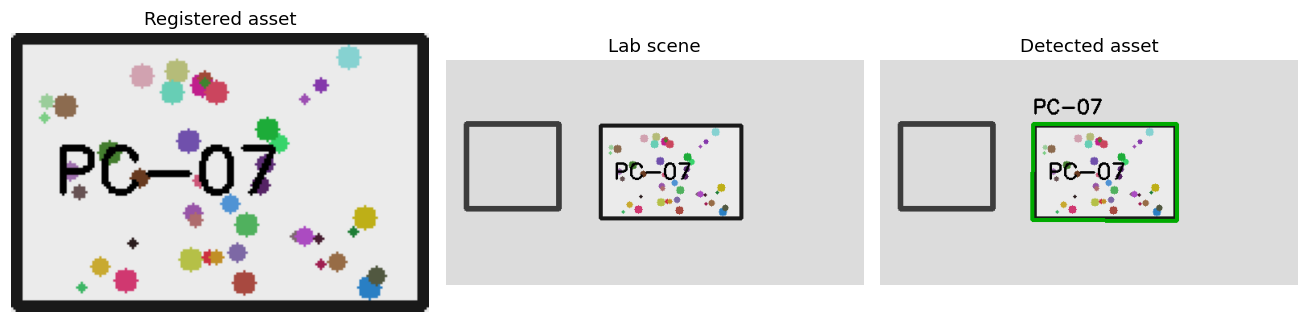

In [6]:
asset_scene = np.full((280, 520, 3), 220, np.uint8)
asset_scene[80:200, 190:370] = asset
cv2.rectangle(asset_scene, (25, 80), (140, 185), (60, 60, 60), 5)
corners, matches = sift_location(asset, asset_scene)
asset_result = asset_scene.copy()
if corners is not None:
    cv2.polylines(asset_result, [corners], True, (0, 170, 0), 3)
    cv2.putText(asset_result, 'PC-07', (190, 67), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)
print('Asset found:', corners is not None, '| RANSAC inlier matches:', matches)
show_images([asset, asset_scene, asset_result], ['Registered asset', 'Lab scene', 'Detected asset'])


## Lab Timing 3 — sensor anomaly detection with a Haar wavelet

The manual introduces the discrete wavelet transform for signal analysis. A Haar wavelet repeatedly splits a signal into averages and details. Here the coarse part gives a smooth baseline; large differences from it are marked as anomalies. The threshold is a simple example and should be calibrated for a real sensor.


Anomaly sample positions: [80, 190, 315, 430]


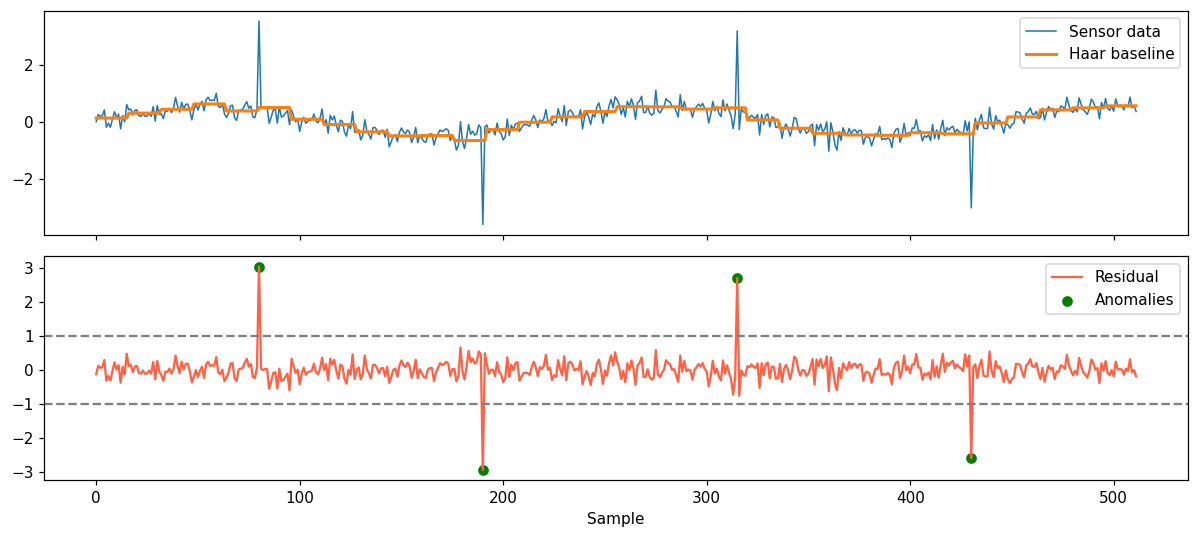

In [8]:
rng = np.random.default_rng(12)
t = np.arange(512)
sensor = 0.5 * np.sin(t / 35) + rng.normal(0, 0.22, len(t))
sensor[[80, 190, 315, 430]] += [3.0, -3.2, 3.3, -3.0]

# Four Haar approximation levels: each pair is replaced by its average.
coarse = sensor.copy()
for _ in range(4):
    coarse = (coarse[::2] + coarse[1::2]) / 2
baseline = np.repeat(coarse, 16)
residual = sensor - baseline
threshold = 3 * np.std(residual)
anomalies = np.flatnonzero(np.abs(residual) > threshold)
print('Anomaly sample positions:', anomalies.tolist())

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(t, sensor, label='Sensor data', linewidth=1)
axes[0].plot(t, baseline, label='Haar baseline', linewidth=2)
axes[0].legend()
axes[1].plot(t, residual, color='tomato', label='Residual')
axes[1].scatter(anomalies, residual[anomalies], color='green', label='Anomalies')
axes[1].axhline(threshold, color='gray', linestyle='--')
axes[1].axhline(-threshold, color='gray', linestyle='--')
axes[1].legend()
axes[1].set_xlabel('Sample')
plt.tight_layout()
plt.show()


## Lab Task 1 — object recognition in video with SIFT

A short sample video is created and read frame by frame. SIFT matches the reference image in each frame. RANSAC rejects inconsistent matches, and a polygon shows the object's location. To use a real video, replace the temporary video path with your file and replace `asset` with a cropped reference photo.


Video frames processed: 3
Object found in each frame: [True, True, True]


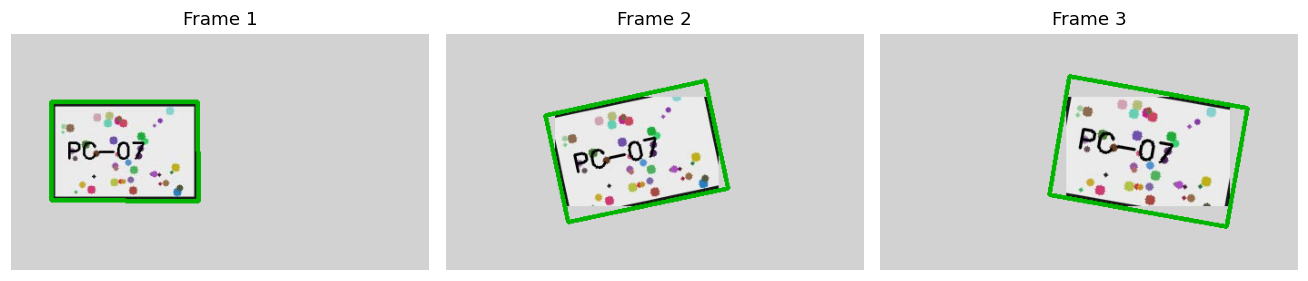

In [10]:
frames = []
for x, scale, angle in [(35, 0.9, 0), (120, 1.0, 12), (205, 1.1, -10)]:
    frame = np.full((260, 460, 3), 210, np.uint8)
    h, w = asset.shape[:2]
    transform = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    transformed = cv2.warpAffine(asset, transform, (w, h), borderValue=(210, 210, 210))
    frame[70:190, x:x + 180] = transformed
    frames.append(frame)

with tempfile.TemporaryDirectory() as folder:
    video_path = str(Path(folder) / 'sample.avi')
    writer = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'MJPG'), 2, (460, 260))
    if not writer.isOpened():
        raise RuntimeError('Could not create the sample video.')
    for frame in frames:
        writer.write(frame)
    writer.release()
    capture = cv2.VideoCapture(video_path)
    detected_frames = []
    found = []
    while True:
        ok, frame = capture.read()
        if not ok:
            break
        corners, matches = sift_location(asset, frame)
        if corners is not None:
            cv2.polylines(frame, [corners], True, (0, 180, 0), 3)
        detected_frames.append(frame)
        found.append(corners is not None)
    capture.release()

print('Video frames processed:', len(detected_frames))
print('Object found in each frame:', found)
show_images(detected_frames, ['Frame 1', 'Frame 2', 'Frame 3'])


## Lab Task 2 — panoramic image with SIFT

Two overlapping views are matched by SIFT. A homography aligns the right view with the left, and their pixels are combined. The sample uses crops from one generated scene so that the overlap is known. Real handheld photos can have exposure and parallax differences, which may need blending and cropping.


SIFT matches: 49 | RANSAC inliers: 41


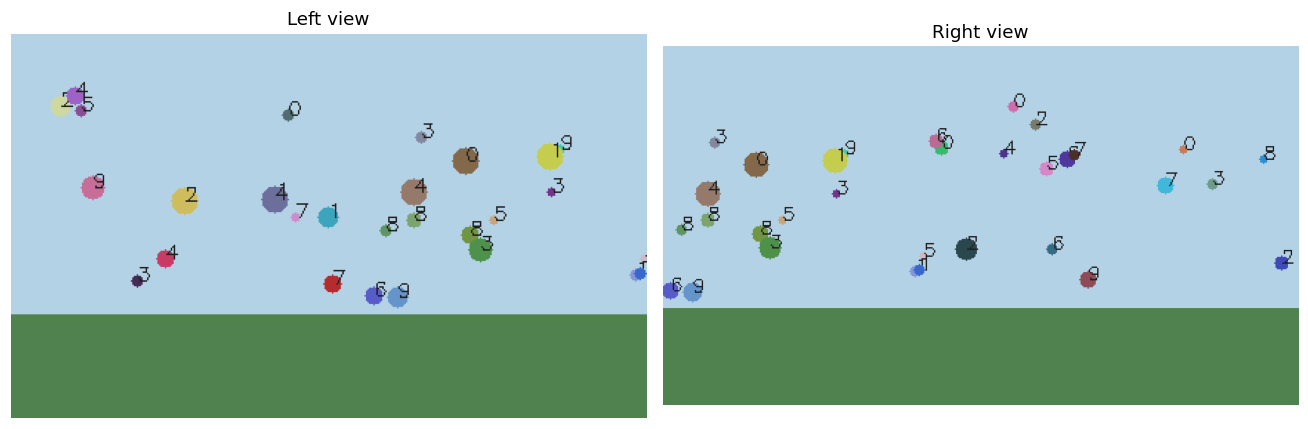

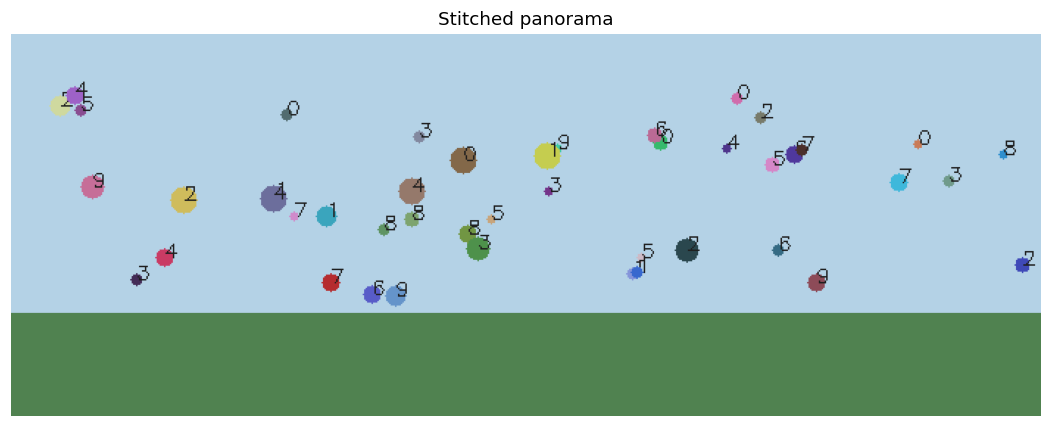

In [12]:
rng = np.random.default_rng(20)
world = np.full((260, 700, 3), (230, 210, 180), np.uint8)
cv2.rectangle(world, (0, 190), (700, 260), (80, 130, 80), -1)
for i in range(45):
    x = int(rng.integers(10, 690))
    y = int(rng.integers(35, 180))
    color = tuple(int(v) for v in rng.integers(40, 220, 3))
    cv2.circle(world, (x, y), int(rng.integers(3, 10)), color, -1)
    cv2.putText(world, str(i % 10), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (30, 30, 30), 1)
left = world[:, :430].copy()
right = world[:, 240:].copy()

sift = cv2.SIFT_create()
k1, d1 = sift.detectAndCompute(cv2.cvtColor(left, cv2.COLOR_BGR2GRAY), None)
k2, d2 = sift.detectAndCompute(cv2.cvtColor(right, cv2.COLOR_BGR2GRAY), None)
pairs = cv2.BFMatcher().knnMatch(d2, d1, k=2)
good = [a for a, b in pairs if a.distance < 0.75 * b.distance]
if len(good) < 4:
    raise RuntimeError('Not enough matching points to stitch images.')
source = np.float32([k2[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
target = np.float32([k1[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
H, inliers = cv2.findHomography(source, target, cv2.RANSAC, 5.0)
if H is None:
    raise RuntimeError('Could not align the images.')
panorama = cv2.warpPerspective(right, H, (700, 260))
panorama[:, :430] = left
print('SIFT matches:', len(good), '| RANSAC inliers:', int(inliers.sum()))
show_images([left, right], ['Left view', 'Right view'])
show_images([panorama], ['Stitched panorama'], size=(11, 4))


## Lab Task 3 — lane detection using Hough lines

The manual's Hough line method votes for straight lines in a Canny edge image. A bottom region of interest and a slope filter keep lane-like segments in this sample road image. Camera placement and road conditions change the useful thresholds.


Lane-like Hough segments: 8


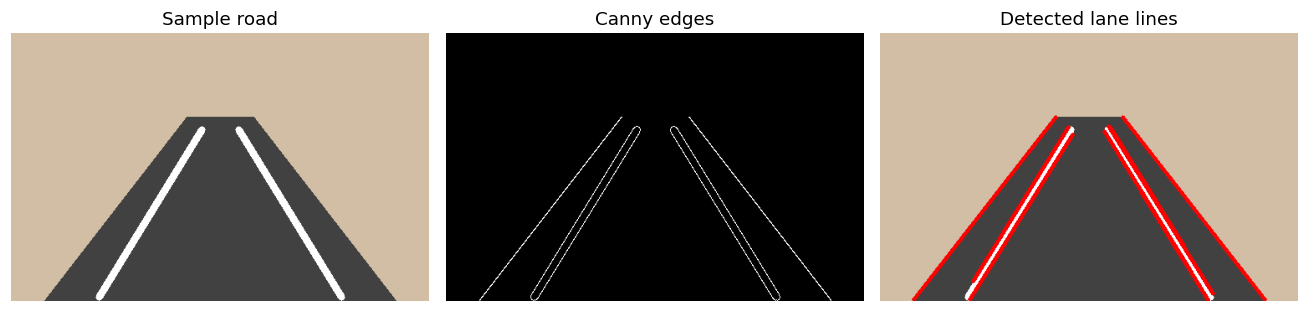

In [14]:
road = np.full((320, 500, 3), (165, 190, 210), np.uint8)
cv2.fillPoly(road, [np.array([[40, 319], [210, 100], [290, 100], [460, 319]])], (65, 65, 65))
cv2.line(road, (105, 315), (228, 115), (255, 255, 255), 8)
cv2.line(road, (395, 315), (272, 115), (255, 255, 255), 8)
gray = cv2.cvtColor(road, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)
edges[:100] = 0
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 45, minLineLength=55, maxLineGap=30)
lane_result = road.copy()
count = 0
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0]:
        slope = (y2 - y1) / (x2 - x1 + 1e-6)
        if abs(slope) > 0.5:
            cv2.line(lane_result, (x1, y1), (x2, y2), (0, 0, 255), 4)
            count += 1
print('Lane-like Hough segments:', count)
show_images([road, edges, lane_result], ['Sample road', 'Canny edges', 'Detected lane lines'])


## Lab Task 4 — coin detection and counting

The Hough circle transform votes for circle centers and radii. Gaussian blur reduces small edge noise before voting. Radius limits and the minimum distance help avoid duplicates; they need adjustment for real coin images.


Coins counted: 5


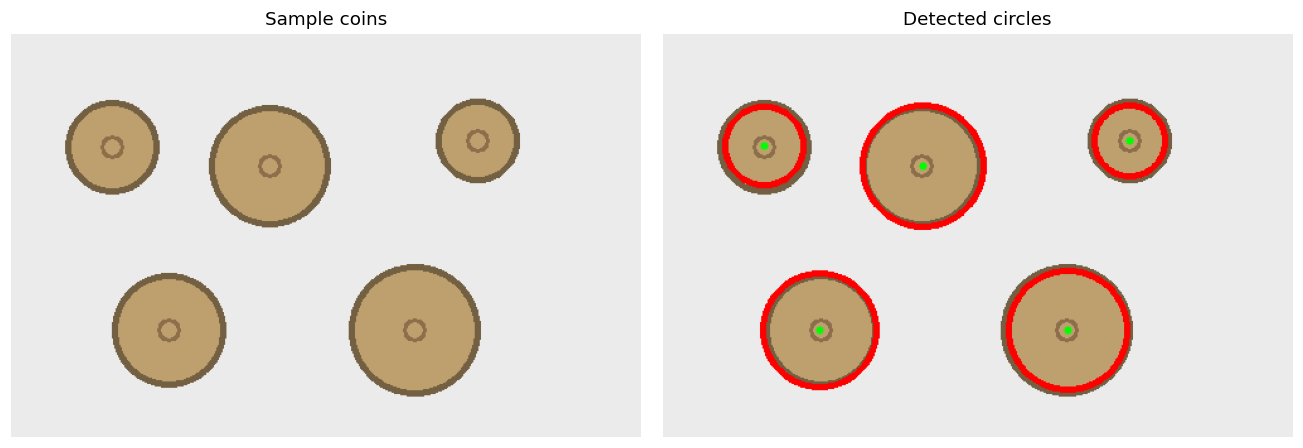

In [16]:
coins_image = np.full((320, 500, 3), 235, np.uint8)
sample_coins = [(80, 90, 35), (205, 105, 46), (370, 85, 31), (125, 235, 43), (320, 235, 50)]
for x, y, r in sample_coins:
    cv2.circle(coins_image, (x, y), r, (110, 160, 190), -1)
    cv2.circle(coins_image, (x, y), r, (65, 95, 115), 3)
    cv2.circle(coins_image, (x, y), 8, (75, 110, 140), 2)
gray = cv2.cvtColor(coins_image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 2)
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp=1.2, minDist=65,
                          param1=100, param2=35, minRadius=25, maxRadius=55)
coin_result = coins_image.copy()
count = 0 if circles is None else len(circles[0])
if circles is not None:
    for x, y, r in np.round(circles[0]).astype(int):
        cv2.circle(coin_result, (x, y), r, (0, 0, 255), 3)
        cv2.circle(coin_result, (x, y), 3, (0, 255, 0), -1)
print('Coins counted:', count)
show_images([coins_image, coin_result], ['Sample coins', 'Detected circles'])


## Lab Task 5 — smart security zone

For each sample video frame, Canny finds object boundaries and contours provide bounding boxes. The green rectangle is the predefined security zone. An alarm is triggered when a detected object's center enters it. This detects an intrusion in a controlled scene; deciding whether a real object is *unauthorized* requires an additional identity or access rule.


Alarm states: ['CLEAR', 'CLEAR', 'ALARM']


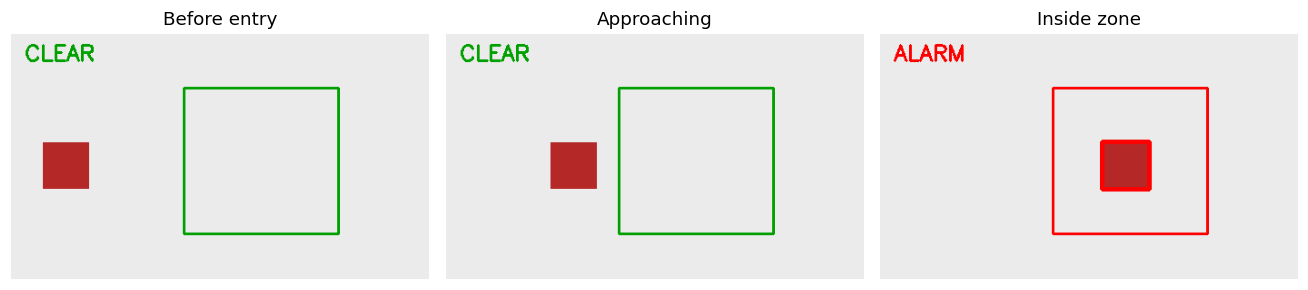

In [18]:
zone = (190, 60, 360, 220)  # left, top, right, bottom
security_frames = []
for x in [35, 115, 245]:
    frame = np.full((270, 460, 3), 235, np.uint8)
    cv2.rectangle(frame, (x, 120), (x + 50, 170), (40, 40, 180), -1)
    security_frames.append(frame)

results = []
states = []
for frame in security_frames:
    edges = cv2.Canny(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    display = frame.copy()
    alarm = False
    for contour in contours:
        if cv2.contourArea(contour) < 500:
            continue
        x, y, w, h = cv2.boundingRect(contour)
        center_x, center_y = x + w // 2, y + h // 2
        if zone[0] <= center_x <= zone[2] and zone[1] <= center_y <= zone[3]:
            alarm = True
            cv2.rectangle(display, (x, y), (x + w, y + h), (0, 0, 255), 3)
    color = (0, 0, 255) if alarm else (0, 160, 0)
    cv2.rectangle(display, zone[:2], zone[2:], color, 2)
    cv2.putText(display, 'ALARM' if alarm else 'CLEAR', (15, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    results.append(display)
    states.append('ALARM' if alarm else 'CLEAR')
print('Alarm states:', states)
show_images(results, ['Before entry', 'Approaching', 'Inside zone'])


## Summary

The notebook demonstrates the requested transforms and detectors with reproducible sample inputs. For real photos or video, use actual image paths or frames and tune the edge, matching, and Hough thresholds to those inputs. A Hough segment is a line candidate, SIFT identifies an object only when its reference features match, and the security alarm requires an explicit authorization rule in a real deployment.
